### Telco Customer Churn

#### Contexto
A perda acelerada de clientes da base ativa, gerando queda direta na receita recorrente da operadora. A diretoria necessita identificar clientes em risco com antecedência para permitir ações proativas e direcionadas da equipe de retenção.

#### Dicionário de Dados
- `CustomerID` - ID único que identifica cada cliente.

- `Count` - Valor usado em relatórios e painéis para somar o número de clientes em um conjunto filtrado.

- `Country` - O país de residência principal do cliente.

- `State` - O estado de residência principal do cliente.

- `City` - A cidade de residência principal do cliente.

- `Zip Code` - O código postal da residência principal do cliente.

- `Lat Long` - Latitude e longitude combinadas da residência principal do cliente.

- `Latitude` - A latitude da residência principal do cliente.

- `Longitude` - A longitude da residênca principal do cliente.

- `Gender` - O gênero do cliente: Male, Female

- `Senior Citizen` - Indica se o cliente tem mais de 65 anos: Yes, No

- `Partner` - Indica se o cliente tem um(a) parceiro(a): Yes, No

- `Dependents` - Indica se o cliente vive com dependentes: Yes, No. Dependentes podem ser filhos, pais, avós, etc.

- `Tenure Months` - Indica a quantidade total de meses que o cliente é um cliente até a data.

- `Phone Service` - Indica se o cliente assina um serviço de linha telefônica fixa com a companhia: Yes, No

- `Multiple Lines` - Indica se o cliente assina múltiplas linhas telefônicas com a companhia: Yes, No

- `Internet Service` - Indica se o cliente assina um serviço de Internet com a companhia: No, DSL, Fiber Optic, Cable.

- `Online Security` - Indica se o cliente assina um serviço adicional de segurança online fornecido pela companhia: Yes, No

- `Online Backup` - Indica se o cliente assina um serviço adicional de backup online fornecido pela companhia: Yes, No

- `Device Protection` - Indica se o cliente assina um plano adicional de proteção para dispositivos fornecido pela companhia para o seu equipamento de Internet: Yes, No

- `Tech Support` - Indica se o cliente assina um plano adicional de suporte técnico da companhia com tempo de espera reduzido: Yes, No

- `Streaming TV` - Indica se o cliente usa seu serviço de Internet para o stream de programação de televisão de um fornecedor terceiro: Yes, No. A companhia não cobra taxas adicionais por este serviço.

- `Streaming Movies` - Indica se o cliente usa seu serviço de Internet para o stream de filmes de um fornecedor terceiro: Yes, No. A companhia não cobra taxas adicionais por este serviço.

- `Contract` - Indica o tipo de contrato atual do cliente: Month-to-Month, One Year, Two Year.

- `Paperless Billing` - Indica se o cliente escolheu cobrança virtual: Yes, No

- `Payment Method` - Indica como o cliente paga sua conta: Bank Withdrawal, Credit Card, Mailed Check

- `Monthly Charge` - Indica o valor mensal total cobrado do cliente pelos serviços fornecidos pela companhia.

- `Total Charges` - Indica o valor total cobrado do cliente, calculado até a data.

- `Churn Label` - Yes = o cliente deixou a companhia neste trimestre. No = o cliente permaneceu com a companhia. Diretamente relacionado ao Churn Value.

- `Churn Value` - 1 = o cliente deixou a companhia neste trimestre. 0 = o cliente permaneceu com a companhia. Diretamente relacionado ao Churn Label.

- `Churn Score` - Um valor entre 0-100 calculado usando a ferramenta preditiva IBM SPSS Modeler. O modelo incorpora múltiplos fatores conhecidos por causar churn. Quanto maior o valor, maior a chance do cliente deixar a companhia.

- `CLTV` - Customer Lifetime Value. O CLTV predito é calculado usando fórmulas corporataivas e dados existentes. Quanto maior o valor, mais valioso é o cliente. Clientes valiosos devem ser monitorados para o churn.

- `Churn Reason` - O motivo específico que levou o cliente a deixar a companhia.

---

#### 1. Configuração do Ambiente

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = Path("../figures")
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#### 2. Carregamento e Entendimento Inicial dos Dados

In [2]:
# Carrega o conjunto de dados e exibe os 5 primeiros registros
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do conjunto:")
df.head()

Shape dos dados: (7043, 33)

Primeiras linhas do conjunto:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())

print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe(include="all")

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.0,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,2,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531.0,2,NaN,NaN,NaN,20
top,3668-QPYBK,NaN,United States,California,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,No,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,5901,3641,5416,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11.0,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


Nesta primeira interação com os dados, notamos que algumas colunas não possuem variância, isto é, possuem um único valor (`Count`, `Country`, `State`).
Outras, são colunas utilizadas exclusivamente como identificadores (`CustomerID`) ou calculadas a posteriori (`Churn Label`, `Churn Score` e `Churn Reason`). Todas elas colunas podem ser removidas sem prejuízo à análise.

In [4]:
df = df.drop(
    columns=[
        "CustomerID",
        "Count",
        "Country",
        "State",
        "Churn Label",
        "Churn Score",
        "Churn Reason",
    ]
)

Além disso, notamos que a coluna `Total Charges`, apesar de descrita como uma coluna numérica, apresenta o tipo `object`. O que indica a necessidade de um pré-processamento para conversão ao tipo correto. Vamos analisar esta coluna.

In [5]:
# O comando coerce força a conversão ao tipo numérico, atribuindo NaN para os valores que não podem ser convertidos
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df[df["Total Charges"].isnull()]

,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
2234,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0,2578
2438,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0,5504
2568,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0,2048
2667,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0,4950
2856,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0,4740
4331,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0,2019
4687,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0,2299
5104,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0,3763
5719,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0,4890
6772,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0,2342


Identificamos que 11 registros apresentam o valor de `Total Charges` nulo. Isso se deve ao fato de serem clientes novos, com 0 meses de relacionamento com a companhia. Dessa forma, atribuímos o valor de 0 à `Total Charges` para preservar os registros de novos clientes.

In [6]:
df["Total Charges"] = df["Total Charges"].fillna(0)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Lat Long           7043 non-null   str    
 3   Latitude           7043 non-null   float64
 4   Longitude          7043 non-null   float64
 5   Gender             7043 non-null   str    
 6   Senior Citizen     7043 non-null   str    
 7   Partner            7043 non-null   str    
 8   Dependents         7043 non-null   str    
 9   Tenure Months      7043 non-null   int64  
 10  Phone Service      7043 non-null   str    
 11  Multiple Lines     7043 non-null   str    
 12  Internet Service   7043 non-null   str    
 13  Online Security    7043 non-null   str    
 14  Online Backup      7043 non-null   str    
 15  Device Protection  7043 non-null   str    
 16  Tech Support       7043 non-null   

#### 3. Análise Exploratória de Dados (EDA)

##### 3.1. Análise de Valores Faltantes

In [8]:
missing_values = pd.DataFrame(
    {
        "Coluna": df.columns,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    }
)

missing_values = missing_values[missing_values["Missing_Count"].gt(0)].sort_values(
    by="Missing_Percentage", ascending=False
)

missing_values

,Coluna,Missing_Count,Missing_Percentage


Como observado no início da análise, apenas a coluna `Churn Reason` (já removida) possuía valores faltantes.

De qualquer maneira, abaixo construiremos um gráfico para visualização da proporção de valores faltantes por coluna, para futura referência.

In [9]:
if len(missing_values) > 0:
    print(missing_values)

    plt.figure(figsize=(10, 3))
    plt.barh(
        missing_values["Coluna"], missing_values["Missing_Percentage"], color="coral"
    )
    plt.xlabel("Porcentagem de Missing Values (%)")
    plt.title("Distribuição de Missing Values por Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor faltante detectado!")

Nenhum valor faltante detectado!


##### 3.2. Análise da Variável Alvo

In [10]:
# Renomear variável `Churn Value` para `target`
df.rename(columns={"Churn Value": "target"}, inplace=True)

Uma análise dos valores únicos da variável alvo nos mostra que ela já está binarizada e é do tipo inteira (conforme `df.info()`).

In [11]:
df["target"].unique()

array([1, 0])

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Não churn (0): 73.46%
Churn (1): 26.54%


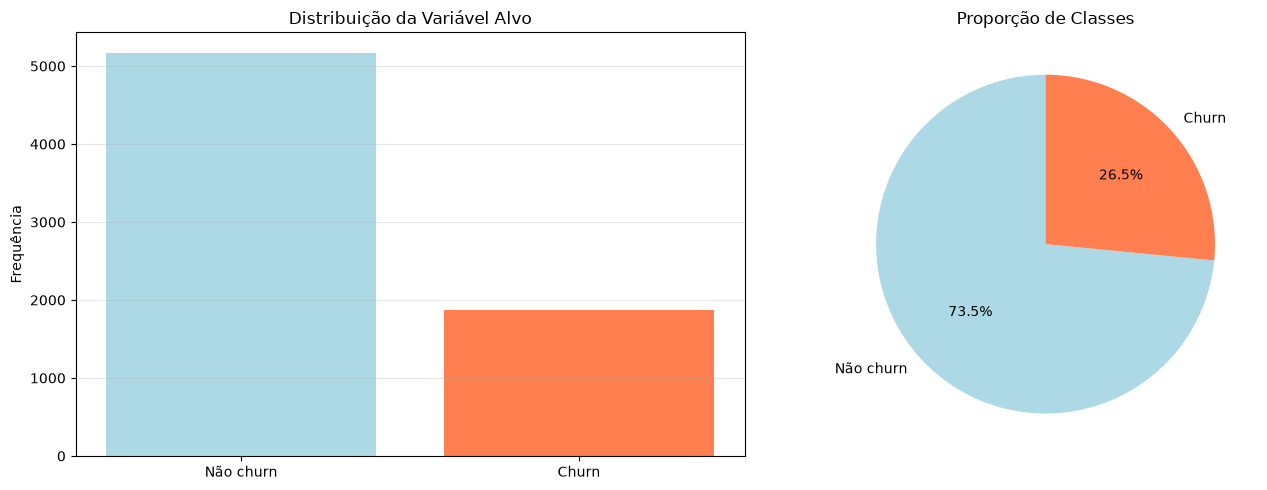


Razão de balanceamento: 0.36
Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [12]:
target_counts = df["target"].value_counts()
target_percentages = df["target"].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)

print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Churn" if idx == 1 else "Não churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Gráfico de barras
axes[0].bar(["Não churn", "Churn"], target_counts.values, color=["lightblue", "coral"])
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição da Variável Alvo')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(target_counts.values, labels=["Não churn", "Churn"], autopct="%1.1f%%", colors=["lightblue", "coral"], startangle=90)
axes[1].set_title('Proporção de Classes')
plt.tight_layout()
plt.show()

# Verifição de desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRazão de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print("Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.")
else:
    print("Dataset razoavelmente balanceado.")

##### 3.3 Análise de Outliers
Objetivo: Identificar valores extremos que podem ser erros de medição ou casos especiais

Métodos utilizados:

- Z-Score: Identifica valores que estão a mais de 3 desvios padrão da média
- Visualização: Boxplots para identificação visual

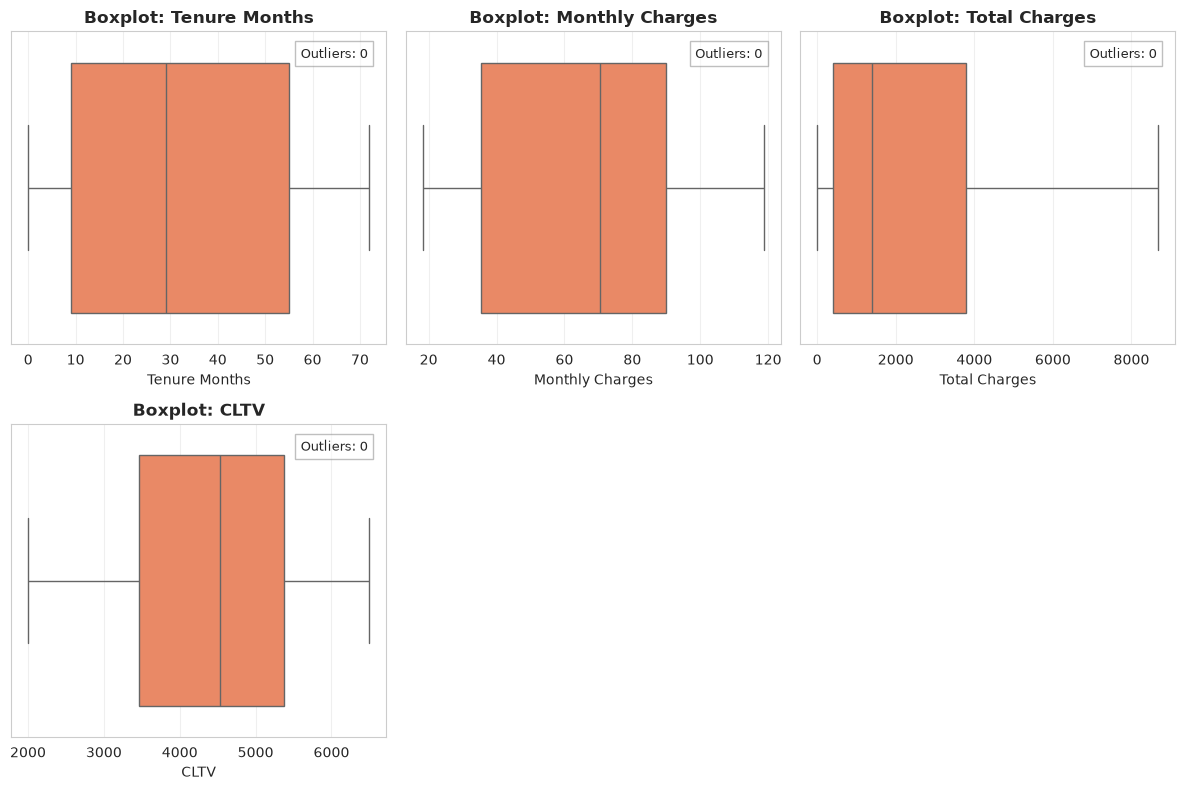

In [19]:
# Colunas numéricas (excluindo colunas que nao fazem sentido para análise de outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(["target", "Zip Code", "Latitude", "Longitude"])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color="coral")
    axes[idx].set_title(f"Boxplot: {col}", fontweight="bold")
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis="x", alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(
        0.95,
        0.95,
        f"Outliers: {outlier_count}",
        transform=axes[idx].transAxes,
        fontsize=9,
        verticalalignment="top",
        horizontalalignment="right",
        bbox={"facecolor": "white", "alpha": 0.5, "edgecolor": "gray"},
    )

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "01_outlier_boxplots.png", dpi=160)

##### 3.4 Churn por Tipo de Contrato
Contratos mensais costumam ter maior risco de churn porque o cliente tem menos barreira para cancelar.

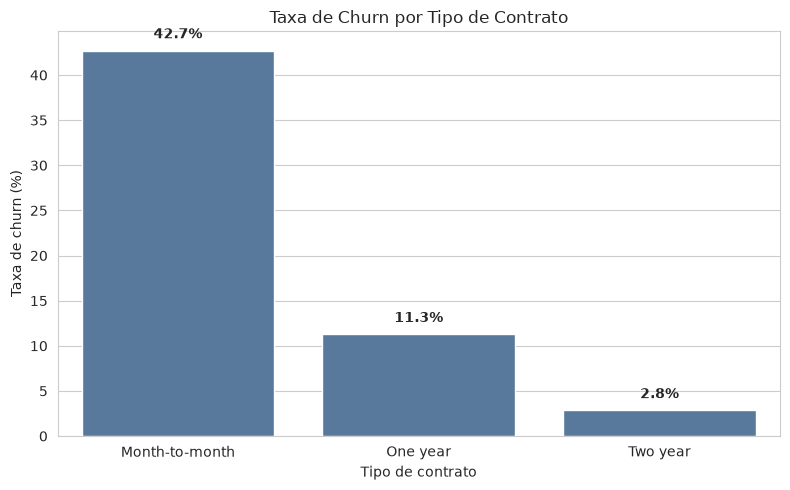

In [ ]:
contract_rate = (
    df.groupby("Contract")["target"]
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .rename("Churn (%)")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=contract_rate.index, y=contract_rate.values, color="#4C78A8", ax=ax)

ax.set_title("Taxa de Churn por Tipo de Contrato")
ax.set_xlabel("Tipo de contrato")
ax.set_ylabel("Taxa de churn (%)")

for i, value in enumerate(contract_rate.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center", va="bottom", fontweight="bold")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_churn_by_contract.png", dpi=160)
# fig

##### 3.5 Churn por Metodo de Pagamento
O metodo de pagamento pode indicar perfis de relacionamento diferentes com a operadora.

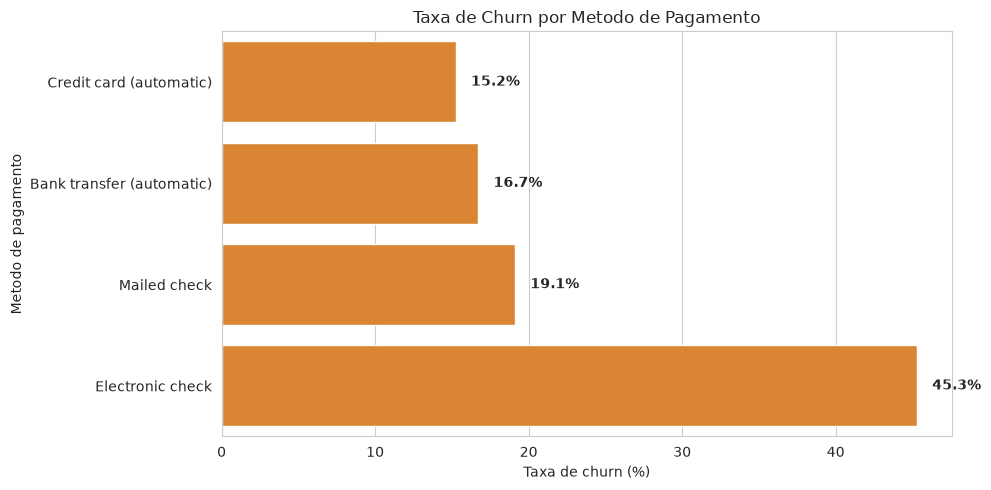

In [16]:
payment_rate = (
    df.groupby("Payment Method", as_index=False)["target"]
    .mean()
    .rename(columns={"Payment Method": "PaymentMethod", "target": "ChurnBinary"})
)
payment_rate["ChurnBinary"] *= 100
payment_rate = payment_rate.sort_values("ChurnBinary", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=payment_rate, y="PaymentMethod", x="ChurnBinary", color="#F58518", ax=ax)
ax.set_title("Taxa de Churn por Metodo de Pagamento")
ax.set_xlabel("Taxa de churn (%)")
ax.set_ylabel("Metodo de pagamento")
for index, value in enumerate(payment_rate["ChurnBinary"]):
    ax.text(value + 1, index, f"{value:.1f}%", va="center", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_churn_by_payment_method.png", dpi=160)

##### 3.6 Tenure por Churn
tenure representa tempo de permanencia. Clientes mais novos podem ter comportamento de churn diferente de clientes antigos.

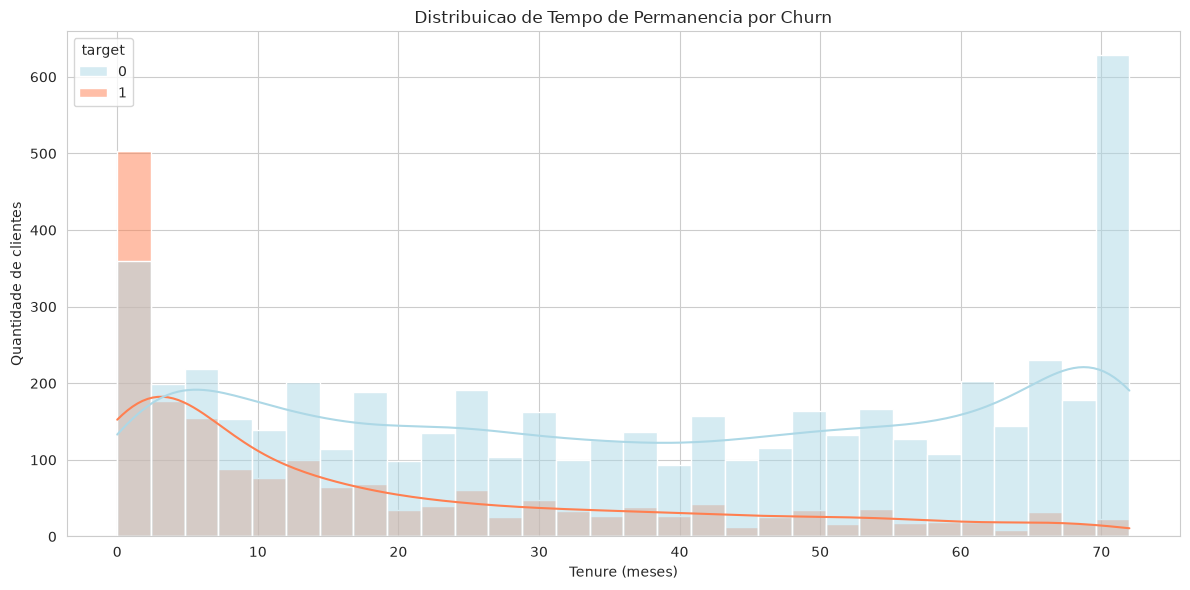

In [17]:
fig, ax = plt.subplots()
sns.histplot(
    data=df,
    x="Tenure Months",
    hue="target",
    hue_order=[0, 1],
    bins=30,
    kde=True,
    palette={0: "lightblue", 1: "coral"},
    ax=ax,
)
ax.set_title("Distribuicao de Tempo de Permanencia por Churn")
ax.set_xlabel("Tenure (meses)")
ax.set_ylabel("Quantidade de clientes")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_tenure_distribution_by_churn.png", dpi=160)

##### 3.7 MonthlyCharges por Churn
A distribuicao de mensalidade ajuda a entender se clientes com churn pagam valores diferentes dos demais.

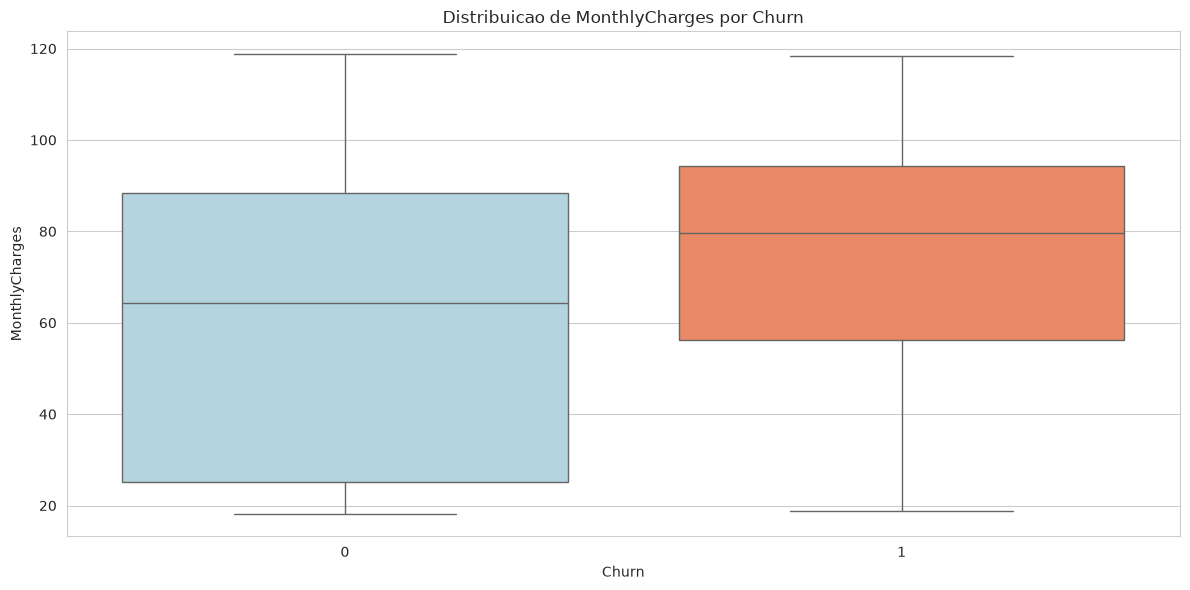

In [18]:
fig, ax = plt.subplots()
sns.boxplot(
    data=df,
    x="target",
    y="Monthly Charges",
    hue="target",
    palette={0: "lightblue", 1: "coral"},
    legend=False,
    ax=ax,
)
ax.set_title("Distribuicao de MonthlyCharges por Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("MonthlyCharges")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_monthly_charges_by_churn.png", dpi=160)

#### 4. Preparação dos dados

##### 4.1. Padronização do nome de colunas

In [ ]:
# Renomeia colunas para lowercase e separação por underscore
df.columns = ["_".join(i.lower().split(" ")) for i in df.columns]

##### 4.2. Remoção de colunas não utilizadas

Para este estudo, desconsideraremos os aspectos geográficos e removeremos as variáveis associadas a eles.

In [57]:
to_drop = ["city", "zip_code", "lat_long", "latitude", "longitude"]
df_clean = df.drop(columns=to_drop)

##### 4.2. Persistência do dataset limpo

In [59]:
df_clean.to_csv("../data/telco_customer_churn_preprocessed.csv", index=False)